# Model Training Notebook — Final Thesis Version

This notebook evaluates whether event-level FBG power features can predict biopsy targeting error.

Modeling stages:
1. Static learnability
2. Static robustness checks
3. Dynamic transfer failure
4. Stable dynamic compensation
5. Final thesis summary outputs

Key modeling choices:
- Final primary feature: `power_energy`
- Final target: absolute event targeting error
- Final model: Ridge regression
- Group-aware splitting by `Trial_File`

In [123]:
'''
IMPORTS
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (
                                        GroupShuffleSplit,
                                        GroupKFold,
                                        cross_val_predict,
                                        cross_val_score,
                                        learning_curve
                                    )
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [124]:
'''
CONFIG + HELPER FUNCTIONS
'''
sns.set(style="whitegrid")
RANDOM_STATE = 42

############################################################################
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
############################################################################
def metric_row(name, y_true, y_pred):
    return {
                "Model": name,
                "R2": r2_score(y_true, y_pred),
                "RMSE": rmse(y_true, y_pred),
                "MAE": mean_absolute_error(y_true, y_pred),
            }
############################################################################
def add_normalized_feature(df):
    df = df.copy()
    df["power_energy_norm"] = (
                                    df["power_energy"] /
                                    df.groupby("Trial_File")["power_energy"].transform("mean")
                               )
    return df
############################################################################

In [125]:
'''
MODELS
'''
primary_model = Pipeline([
                            ("scaler", StandardScaler()),
                            ("ridge", Ridge(alpha=1.0))
                        ])

baseline_model = DummyRegressor(strategy="mean")

In [126]:
'''
LOADING DATASETS
'''
df_static = pd.read_csv("static_ideal_event_train.csv")
static_df_full = pd.read_csv("static_df.csv")      # full time-series snippets for plotting

df_dynamic = pd.read_csv("dynamic_ideal_event_train.csv")
dynamic_df_full = pd.read_csv("dynamic_df.csv")    # full time-series snippets for plotting

In [127]:
'''
FEATURES
'''

# Columns that should never be used as predictors
leaky_cols = [
    "mm_min_value",
    "mm_median",
    "mm_mean",
    "mm_min_time_sec",
    "mm_to_trough_dt_sec",
    "center_to_trough_dt_sec"
]

# Final primary feature set used in the thesis
basic_features = ["power_energy"]

# Exploratory feature set for testing (not final thesis model)
lung_features = [
    "power_energy",
    "Breath_Percent_sin",
    "Breath_Percent_cos",
    "Breath_PWM_scaled",
    "power_breath_at_event",
    "power_minus_breath"
]

In [128]:
'''
TARGET
'''

TARGET_RAW = "mm_min_value"
TARGET = "target_abs_error"

df_static[TARGET] = np.abs(df_static[TARGET_RAW])
df_dynamic[TARGET] = np.abs(df_dynamic[TARGET_RAW])

In [129]:
'''
DEFINING STATIC & DYNAMIC SETS
'''

X_static_basic = df_static[basic_features].copy()
y_static = df_static[TARGET].copy()
groups_static = df_static["Trial_File"].copy()

X_dynamic_basic = df_dynamic[basic_features].copy()
y_dynamic = df_dynamic[TARGET].copy()
groups_dynamic = df_dynamic["Trial_File"].copy()

print("Static shape:", df_static.shape)
print("Dynamic shape:", df_dynamic.shape)

Static shape: (64, 33)
Dynamic shape: (39, 32)


STATIC DATASET SUMMARY
----------------------
Total events: 64
Total trial files: 25

Events per class:
Nominal_Class
0mm    22
1mm    21
2mm    21
Name: count, dtype: int64

Trial files per class:
Nominal_Class
0mm    9
1mm    8
2mm    8
Name: Trial_File, dtype: int64


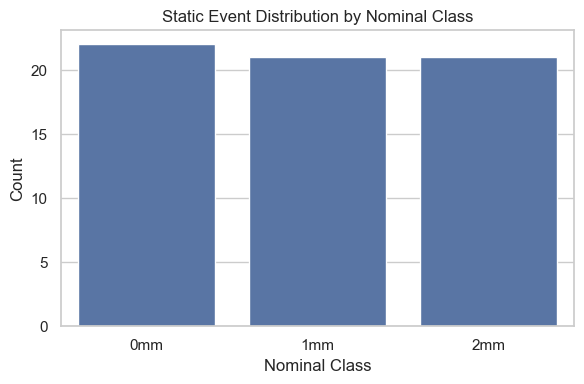

In [130]:
print("STATIC DATASET SUMMARY")
print("----------------------")
print(f"Total events: {len(df_static)}")
print(f"Total trial files: {df_static['Trial_File'].nunique()}")

print("\nEvents per class:")
print(df_static["Nominal_Class"].value_counts())

print("\nTrial files per class:")
print(df_static.groupby("Nominal_Class")["Trial_File"].nunique())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_static, x="Nominal_Class")
plt.title("Static Event Distribution by Nominal Class")
plt.xlabel("Nominal Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

DYNAMIC DATASET SUMMARY
----------------------
Total events: 39
Total trial files: 13

Events per class:
Nominal_Class
0mm    15
1mm    12
2mm    12
Name: count, dtype: int64

Trial files per class:
Nominal_Class
0mm    5
1mm    4
2mm    4
Name: Trial_File, dtype: int64


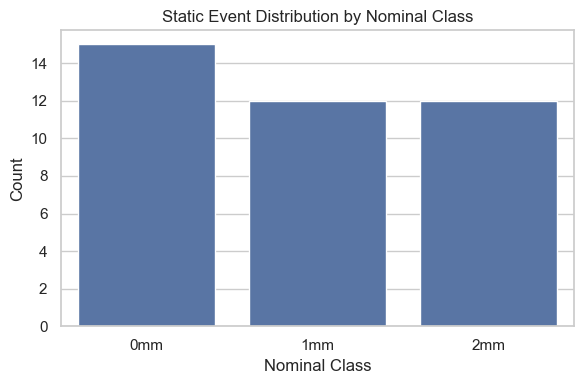

In [131]:
print("DYNAMIC DATASET SUMMARY")
print("----------------------")
print(f"Total events: {len(df_dynamic)}")
print(f"Total trial files: {df_dynamic['Trial_File'].nunique()}")

print("\nEvents per class:")
print(df_dynamic["Nominal_Class"].value_counts())

print("\nTrial files per class:")
print(df_dynamic.groupby("Nominal_Class")["Trial_File"].nunique())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_dynamic, x="Nominal_Class")
plt.title("Static Event Distribution by Nominal Class")
plt.xlabel("Nominal Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

---
### **STAGE 1**: STATIC MODEL
---

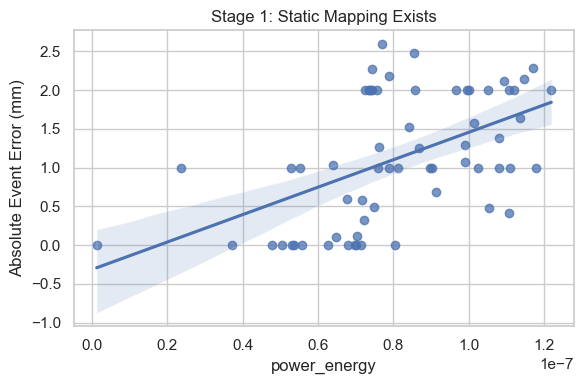

Pearson r(power_energy, absolute error) = 0.513


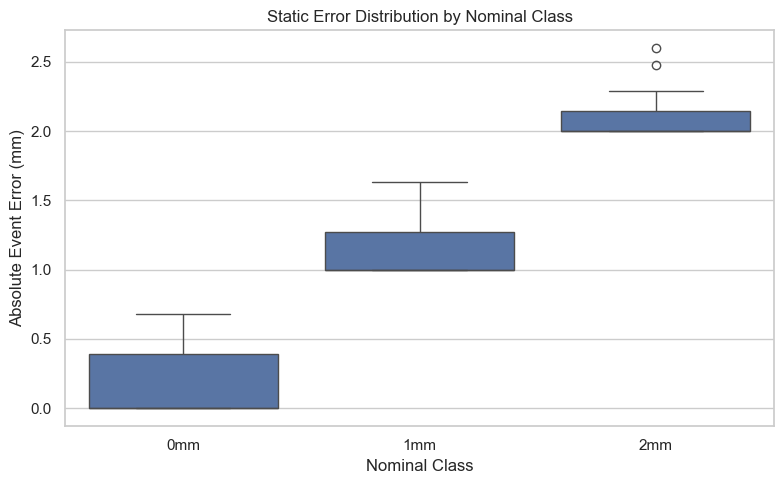

In [132]:
'''
STATIC FEATURE-TARGET RELATIONSHIP DATA ANALYSIS
'''

plt.figure(figsize=(6, 4))
sns.regplot(
                x=df_static["power_energy"],
                y=df_static[TARGET],
                scatter_kws={"alpha": 0.75}
            )
plt.xlabel("power_energy")
plt.ylabel("Absolute Event Error (mm)")
plt.title("Stage 1: Static Mapping Exists")
plt.tight_layout()
plt.show()

corr = np.corrcoef(df_static["power_energy"], df_static[TARGET])[0, 1]
print(f"Pearson r(power_energy, absolute error) = {corr:.3f}")

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_static, x="Nominal_Class", y=TARGET)
plt.title("Static Error Distribution by Nominal Class")
plt.xlabel("Nominal Class")
plt.ylabel("Absolute Event Error (mm)")
plt.tight_layout()
plt.show()

In [133]:
'''
GROUPED TRAIN / TEST SPLIT
'''
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_static_basic, y_static, groups=groups_static))

X_train_basic = X_static_basic.iloc[train_idx]
X_test_basic = X_static_basic.iloc[test_idx]

y_train_static = y_static.iloc[train_idx]
y_test_static = y_static.iloc[test_idx]

groups_train_static = groups_static.iloc[train_idx]
groups_test_static = groups_static.iloc[test_idx]

gkf_static = GroupKFold(n_splits=min(5, groups_static.nunique()))

print("Train groups:", groups_train_static.nunique())
print("Test groups:", groups_test_static.nunique())

Train groups: 18
Test groups: 7


In [134]:
'''
MODEL FITTING
'''

# Primary model
static_basic_model = clone(primary_model)
static_basic_model.fit(X_train_basic, y_train_static)
y_test_pred_static = static_basic_model.predict(X_test_basic)

# Dummy baseline
dummy_fit = clone(baseline_model)
dummy_fit.fit(X_train_basic, y_train_static)
y_test_pred_dummy = dummy_fit.predict(X_test_basic)

In [135]:
print("STATIC HELD-OUT PERFORMANCE")
print("---------------------------")
print(f"Baseline MAE: {mean_absolute_error(y_test_static, y_test_pred_dummy):.3f}")
print(f"Model MAE: {mean_absolute_error(y_test_static, y_test_pred_static):.3f}")
print()
print(f"Baseline R2: {r2_score(y_test_static, y_test_pred_dummy):.3f}")
print(f"Model R2: {r2_score(y_test_static, y_test_pred_static):.3f}")

ridge_coef = static_basic_model.named_steps["ridge"].coef_[0]
ridge_intercept = static_basic_model.named_steps["ridge"].intercept_

print()
print(f"Ridge coefficient (power_energy): {ridge_coef:.6f}")
print(f"Ridge intercept: {ridge_intercept:.6f}")

STATIC HELD-OUT PERFORMANCE
---------------------------
Baseline MAE: 0.494
Model MAE: 0.523

Baseline R2: -0.083
Model R2: 0.056

Ridge coefficient (power_energy): 0.462469
Ridge intercept: 1.179034


In [136]:
'''
STATIC GROUPED CV
'''

cv_r2_static = cross_val_score(
                                clone(primary_model),
                                X_static_basic,
                                y_static,
                                cv=gkf_static,
                                groups=groups_static,
                                scoring="r2",
                                n_jobs=-1
                            )

cv_rmse_static = -cross_val_score(
                                    clone(primary_model),
                                    X_static_basic,
                                    y_static,
                                    cv=gkf_static,
                                    groups=groups_static,
                                    scoring="neg_root_mean_squared_error",
                                    n_jobs=-1
                                )

cv_mae_static = -cross_val_score(
                                    clone(primary_model),
                                    X_static_basic,
                                    y_static,
                                    cv=gkf_static,
                                    groups=groups_static,
                                    scoring="neg_mean_absolute_error",
                                    n_jobs=-1
                                )

In [137]:
print("STATIC GROUPED CV SUMMARY")
print("-------------------------")
print(f"R2 mean ± std: {cv_r2_static.mean():.3f} ± {cv_r2_static.std():.3f}")
print(f"RMSE mean ± std: {cv_rmse_static.mean():.3f} ± {cv_rmse_static.std():.3f}")
print(f"MAE mean ± std: {cv_mae_static.mean():.3f} ± {cv_mae_static.std():.3f}")

STATIC GROUPED CV SUMMARY
-------------------------
R2 mean ± std: 0.244 ± 0.279
RMSE mean ± std: 0.680 ± 0.254
MAE mean ± std: 0.627 ± 0.261


In [138]:
'''
STATIC GROUPED CV PREDICTIONS
'''

cv_pred_static = cross_val_predict(
                                        clone(primary_model),
                                        X_static_basic,
                                        y_static,
                                        groups=groups_static,
                                        cv=gkf_static,
                                        n_jobs=-1
                                    )

cv_pred_static_df = pd.DataFrame({
                                        "Trial_File": groups_static.values,
                                        "Nominal_Class": df_static["Nominal_Class"].values,
                                        "y_true": y_static.values,
                                        "y_pred": cv_pred_static
                                    })

cv_pred_static_df["abs_error"] = np.abs(cv_pred_static_df["y_true"] - cv_pred_static_df["y_pred"])

In [139]:
print("STATIC CV OVERALL")
print("-----------------")
print("R2:", r2_score(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]))
print("RMSE:", rmse(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]))
print("MAE:", mean_absolute_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]))

STATIC CV OVERALL
-----------------
R2: 0.21877390807725228
RMSE: 0.7223432743145359
MAE: 0.6232516735848368


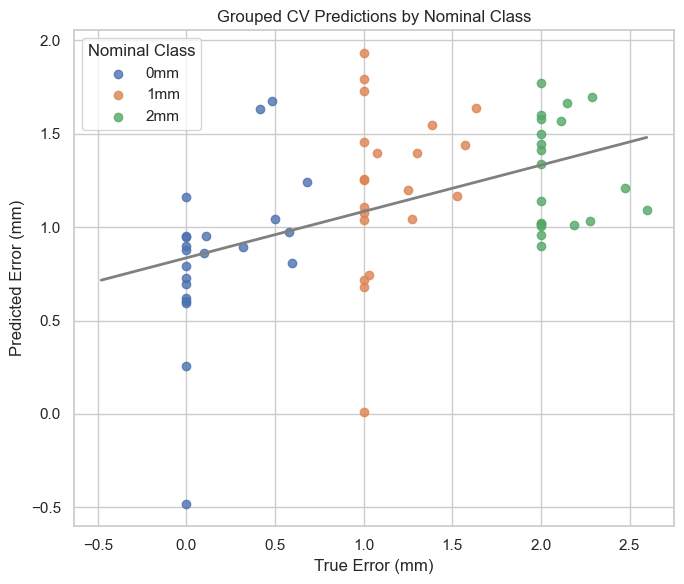

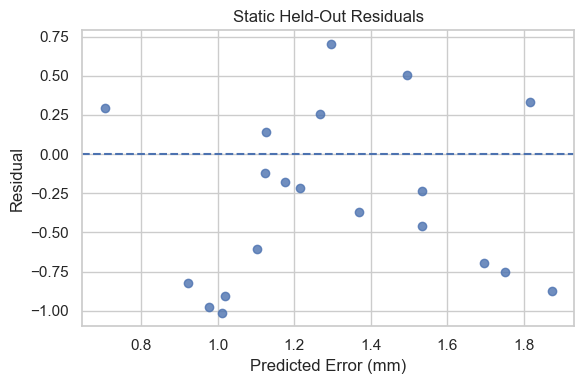

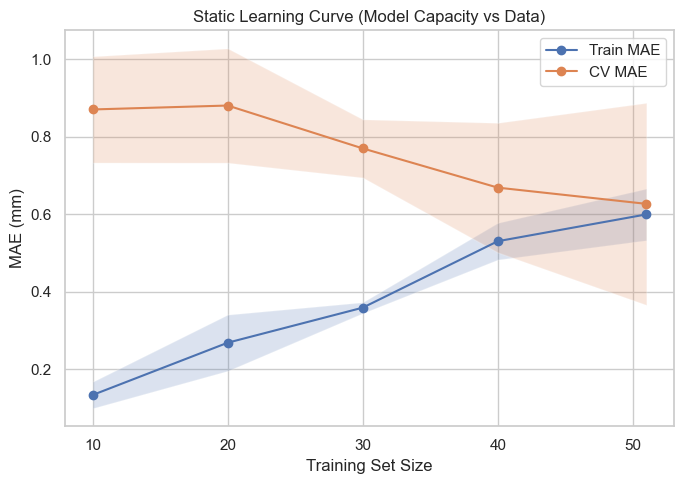

In [140]:
'''
STATIC CV EVAL PLOTS
'''

# Held-out actual vs predicted
plt.figure(figsize=(7, 6))

for cls in sorted(cv_pred_static_df["Nominal_Class"].unique()):
    g = cv_pred_static_df[cv_pred_static_df["Nominal_Class"] == cls]
    plt.scatter(g["y_true"], g["y_pred"], alpha=0.8, label=cls)

lims = [
    min(cv_pred_static_df["y_true"].min(), cv_pred_static_df["y_pred"].min()),
    max(cv_pred_static_df["y_true"].max(), cv_pred_static_df["y_pred"].max())
]

# best-fit line on y_true
m, b = np.polyfit(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"], 1)
xline = np.linspace(lims[0], lims[1], 100)
plt.plot(xline, m * xline + b, "-", color="gray", linewidth=2)

plt.xlabel("True Error (mm)")
plt.ylabel("Predicted Error (mm)")
plt.title("Grouped CV Predictions by Nominal Class")
plt.legend(title="Nominal Class")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual plot
residuals_static = y_test_static - y_test_pred_static
plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred_static, residuals_static, alpha=0.8)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Error (mm)")
plt.ylabel("Residual")
plt.title("Static Held-Out Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
                                                            estimator=clone(primary_model),
                                                            X=X_static_basic,
                                                            y=y_static,
                                                            groups=groups_static,
                                                            cv=gkf_static,
                                                            scoring="neg_mean_absolute_error",
                                                            train_sizes=np.linspace(0.2, 1.0, 5),
                                                            n_jobs=-1
                                                        )

train_mae = -train_scores.mean(axis=1)
train_mae_std = train_scores.std(axis=1)
val_mae = -val_scores.mean(axis=1)
val_mae_std = val_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mae, marker="o", label="Train MAE")
plt.fill_between(train_sizes, train_mae - train_mae_std, train_mae + train_mae_std, alpha=0.2)
plt.plot(train_sizes, val_mae, marker="o", label="CV MAE")
plt.fill_between(train_sizes, val_mae - val_mae_std, val_mae + val_mae_std, alpha=0.2)
plt.xlabel("Training Set Size")
plt.ylabel("MAE (mm)")
plt.title("Static Learning Curve (Model Capacity vs Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [141]:
'''
STAGE 1 ROBUSTNESS CHECK 1
REPEATED GROUP HOLD OUT
'''
# Repeated grouped holdout
n_repeats = 100
repeated_rows = []

splitter = GroupShuffleSplit(
                                n_splits=n_repeats,
                                test_size=0.25,
                                random_state=RANDOM_STATE
                            )

for split_id, (tr_idx, te_idx) in enumerate(splitter.split(X_static_basic, y_static, groups_static)):
    X_tr = X_static_basic.iloc[tr_idx]
    X_te = X_static_basic.iloc[te_idx]
    y_tr = y_static.iloc[tr_idx]
    y_te = y_static.iloc[te_idx]

    model = clone(primary_model)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    repeated_rows.append({
                            "split": split_id,
                            "R2": r2_score(y_te, pred),
                            "RMSE": rmse(y_te, pred),
                            "MAE": mean_absolute_error(y_te, pred)
                        })

repeated_results_df = pd.DataFrame(repeated_rows)

In [142]:
print("REPEATED GROUPED HOLDOUT SUMMARY")
print("--------------------------------")
print(repeated_results_df[["R2", "RMSE", "MAE"]].describe())
print()
print(f"Median R2: {repeated_results_df['R2'].median():.3f}")
print(f"Median RMSE: {repeated_results_df['RMSE'].median():.3f}")
print(f"Median MAE: {repeated_results_df['MAE'].median():.3f}")
print(f"% splits with R2 > 0: {(repeated_results_df['R2'] > 0).mean() * 100:.1f}%")

REPEATED GROUPED HOLDOUT SUMMARY
--------------------------------
               R2        RMSE         MAE
count  100.000000  100.000000  100.000000
mean    -0.031373    0.741145    0.646475
std      0.688450    0.119292    0.119095
min     -5.551730    0.425910    0.365785
25%     -0.072979    0.664421    0.567776
50%      0.106968    0.747701    0.644780
75%      0.296300    0.810402    0.718172
max      0.549744    1.079044    0.963159

Median R2: 0.107
Median RMSE: 0.748
Median MAE: 0.645
% splits with R2 > 0: 65.0%


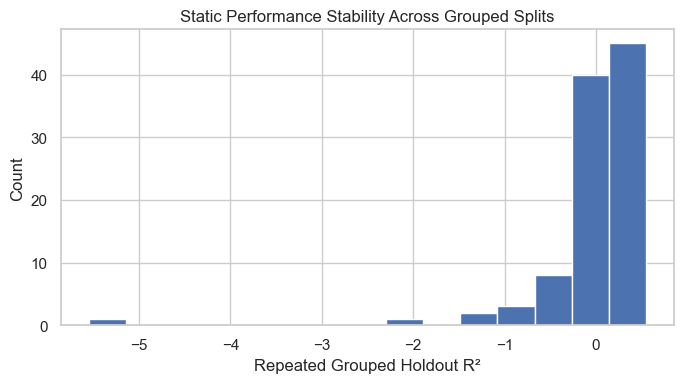

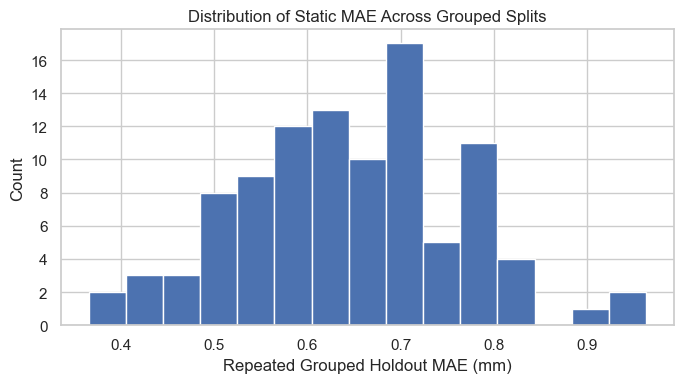

In [143]:
plt.figure(figsize=(7, 4))
plt.hist(repeated_results_df["R2"], bins=15)
plt.xlabel("Repeated Grouped Holdout R²")
plt.ylabel("Count")
plt.title("Static Performance Stability Across Grouped Splits")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(repeated_results_df["MAE"], bins=15)
plt.xlabel("Repeated Grouped Holdout MAE (mm)")
plt.ylabel("Count")
plt.title("Distribution of Static MAE Across Grouped Splits")
plt.grid(True)
plt.tight_layout()
plt.show()

In [144]:
'''
STAGE 1 ROBUSTNESS CHECK 2
SHUFFLED LABEL SANITY TEST
'''

# Shuffled-label sanity test
rng = np.random.default_rng(RANDOM_STATE)
y_static_shuffled = pd.Series(rng.permutation(y_static.values), index=y_static.index)

shuffle_r2 = cross_val_score(
                                clone(primary_model),
                                X_static_basic,
                                y_static_shuffled,
                                cv=gkf_static,
                                groups=groups_static,
                                scoring="r2",
                                n_jobs=-1
                            )

shuffle_mae = -cross_val_score(
                                    clone(primary_model),
                                    X_static_basic,
                                    y_static_shuffled,
                                    cv=gkf_static,
                                    groups=groups_static,
                                    scoring="neg_mean_absolute_error",
                                    n_jobs=-1
                                )

In [145]:
print("SHUFFLED-LABEL GROUPED CV SUMMARY")
print("---------------------------------")
print(f"R2 mean ± std: {shuffle_r2.mean():.3f} ± {shuffle_r2.std():.3f}")
print(f"MAE mean ± std: {shuffle_mae.mean():.3f} ± {shuffle_mae.std():.3f}")
print()
print("Real vs shuffled MAE:")
print(f"Real MAE mean: {cv_mae_static.mean():.3f}")
print(f"Shuffled MAE mean: {shuffle_mae.mean():.3f}")

SHUFFLED-LABEL GROUPED CV SUMMARY
---------------------------------
R2 mean ± std: -0.067 ± 0.175
MAE mean ± std: 0.700 ± 0.210

Real vs shuffled MAE:
Real MAE mean: 0.627
Shuffled MAE mean: 0.700


---
### **STAGE 2**: WHY NAIVE MODEL TRANSFER TO DYNAMIC DATA FAILS
---

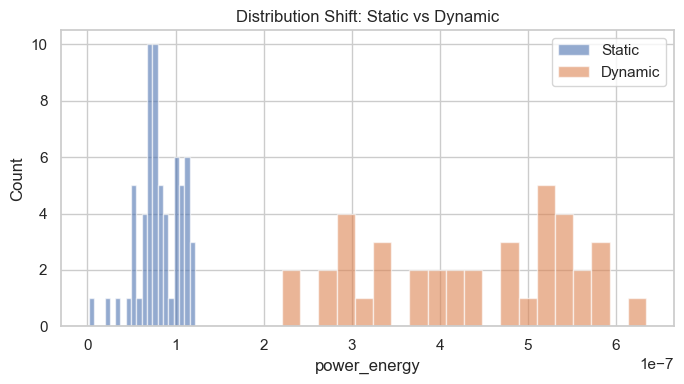

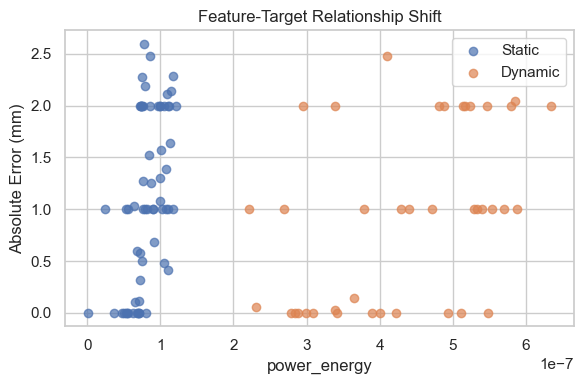

In [146]:
plt.figure(figsize=(7, 4))
plt.hist(df_static["power_energy"], bins=20, alpha=0.6, label="Static")
plt.hist(df_dynamic["power_energy"], bins=20, alpha=0.6, label="Dynamic")
plt.xlabel("power_energy")
plt.ylabel("Count")
plt.title("Distribution Shift: Static vs Dynamic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df_static["power_energy"], df_static[TARGET], label="Static", alpha=0.7)
plt.scatter(df_dynamic["power_energy"], df_dynamic[TARGET], label="Dynamic", alpha=0.7)
plt.xlabel("power_energy")
plt.ylabel("Absolute Error (mm)")
plt.legend()
plt.title("Feature-Target Relationship Shift")
plt.grid(True)
plt.tight_layout()
plt.show()

---
### **STAGE 3**: NAIVE DYNAMIC TRANSFER VS. COMPENSATED TRANSFER
---

In [147]:
'''
NAIVE TRANSFER
'''

model_naive = clone(primary_model)
model_naive.fit(X_static_basic, y_static)
y_pred_dynamic_naive = model_naive.predict(X_dynamic_basic)

In [148]:
'''
COMPENSATED TRANSFER
'''

# Stable compensation via within-trial normalization
df_static_norm = add_normalized_feature(df_static)
df_dynamic_norm = add_normalized_feature(df_dynamic)

X_static_norm = df_static_norm[["power_energy_norm"]].copy()
X_dynamic_norm = df_dynamic_norm[["power_energy_norm"]].copy()

model_comp = clone(primary_model)
model_comp.fit(X_static_norm, y_static)
y_pred_dynamic_comp = model_comp.predict(X_dynamic_norm)

In [149]:
results_dynamic_compare = pd.DataFrame([
                                            metric_row("Naive transfer (raw power_energy)", y_dynamic, y_pred_dynamic_naive),
                                            metric_row("Compensated transfer (within-trial normalized)", y_dynamic, y_pred_dynamic_comp),
                                        ])

In [150]:
print("DYNAMIC MODEL COMPARISON")
print("------------------------")
display(results_dynamic_compare)

DYNAMIC MODEL COMPARISON
------------------------


,Model,R2,RMSE,MAE
0,Naive transfer (raw power_energy),-59.989750,6.582452,6.338316
1,Compensated transfer (within-trial normalized),-0.054809,0.865658,0.748616


In [151]:
'''
DYNAMIC MODEL PLOTTING DFS
'''

class_colors = {
                    "0mm": "tab:blue",
                    "1mm": "tab:orange",
                    "2mm": "tab:green",
                    0: "tab:blue",
                    1: "tab:orange",
                    2: "tab:green"
                }

dynamic_naive_df = pd.DataFrame({
                                    "Nominal_Class": df_dynamic["Nominal_Class"].values,
                                    "y_true": y_dynamic.values if hasattr(y_dynamic, "values") else y_dynamic,
                                    "y_pred": y_pred_dynamic_naive
                                })

dynamic_comp_df = pd.DataFrame({
                                    "Nominal_Class": df_dynamic["Nominal_Class"].values,
                                    "y_true": y_dynamic.values if hasattr(y_dynamic, "values") else y_dynamic,
                                    "y_pred": y_pred_dynamic_comp
                                })

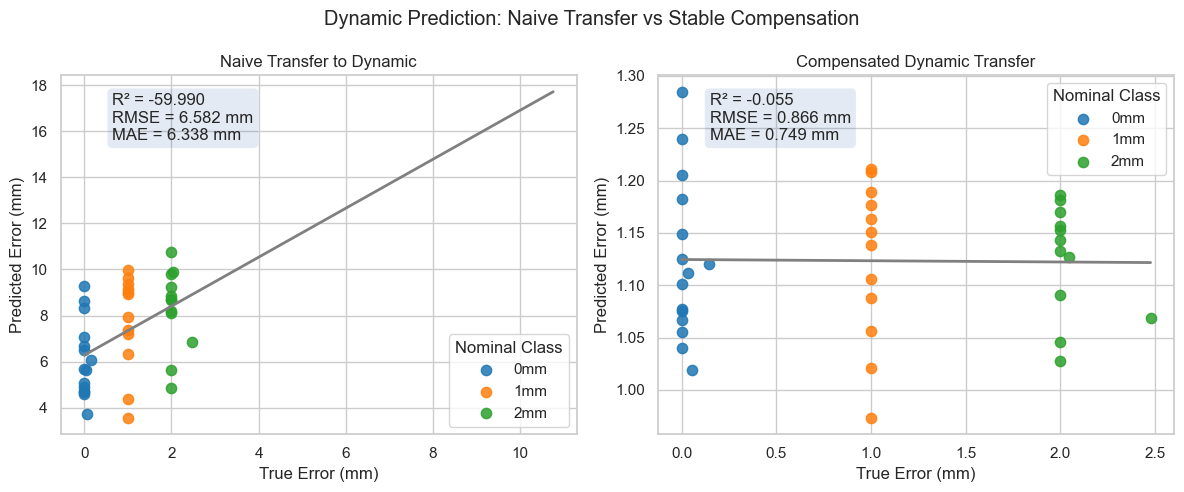

In [152]:
'''
DYNAMIC MODEL COMPARISON EVAL PLOTS
'''

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Naive transfer
# -------------------------
for cls, g in dynamic_naive_df.groupby("Nominal_Class"):
    axes[0].scatter(
        g["y_true"],
        g["y_pred"],
        alpha=0.85,
        s=55,
        label=str(cls),
        color=class_colors.get(cls, None)
    )

lims0 = [
    min(dynamic_naive_df["y_true"].min(), dynamic_naive_df["y_pred"].min()),
    max(dynamic_naive_df["y_true"].max(), dynamic_naive_df["y_pred"].max())
]

m0, b0 = np.polyfit(dynamic_naive_df["y_true"], dynamic_naive_df["y_pred"], 1)
xline0 = np.linspace(lims0[0], lims0[1], 100)
axes[0].plot(xline0, m0 * xline0 + b0, "-", color="gray", linewidth=2)

axes[0].set_title("Naive Transfer to Dynamic")
axes[0].set_xlabel("True Error (mm)")
axes[0].set_ylabel("Predicted Error (mm)")
axes[0].grid(True)
axes[0].legend(title="Nominal Class")

txt0 = (
    f"R² = {r2_score(dynamic_naive_df['y_true'], dynamic_naive_df['y_pred']):.3f}\n"
    f"RMSE = {rmse(dynamic_naive_df['y_true'], dynamic_naive_df['y_pred']):.3f} mm\n"
    f"MAE = {mean_absolute_error(dynamic_naive_df['y_true'], dynamic_naive_df['y_pred']):.3f} mm"
)
axes[0].text(
    0.1, 0.95, txt0,
    transform=axes[0].transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

# -------------------------
# Compensated transfer
# -------------------------
for cls, g in dynamic_comp_df.groupby("Nominal_Class"):
    axes[1].scatter(
        g["y_true"],
        g["y_pred"],
        alpha=0.85,
        s=55,
        label=str(cls),
        color=class_colors.get(cls, None)
    )

lims1 = [
    min(dynamic_comp_df["y_true"].min(), dynamic_comp_df["y_pred"].min()),
    max(dynamic_comp_df["y_true"].max(), dynamic_comp_df["y_pred"].max())
]

m1, b1 = np.polyfit(dynamic_comp_df["y_true"], dynamic_comp_df["y_pred"], 1)
xline1 = np.linspace(lims1[0], lims1[1], 100)
axes[1].plot(xline1, m1 * xline1 + b1, "-", color="gray", linewidth=2)

axes[1].set_title("Compensated Dynamic Transfer")
axes[1].set_xlabel("True Error (mm)")
axes[1].set_ylabel("Predicted Error (mm)")
axes[1].grid(True)
axes[1].legend(title="Nominal Class")

txt1 = (
    f"R² = {r2_score(dynamic_comp_df['y_true'], dynamic_comp_df['y_pred']):.3f}\n"
    f"RMSE = {rmse(dynamic_comp_df['y_true'], dynamic_comp_df['y_pred']):.3f} mm\n"
    f"MAE = {mean_absolute_error(dynamic_comp_df['y_true'], dynamic_comp_df['y_pred']):.3f} mm"
)
axes[1].text(
    0.1, 0.95, txt1,
    transform=axes[1].transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.suptitle("Dynamic Prediction: Naive Transfer vs Stable Compensation")
plt.tight_layout()
plt.show()

---
### **STAGE 4**: DYNAMIC ONLY POST HOC MODELING
---

In [153]:
'''
DYNAMIC-ONLY MODELING SETUP
'''

gkf_dynamic = GroupKFold(n_splits=min(5, groups_dynamic.nunique()))

X_dynamic_stage4 = X_dynamic_basic.copy()
y_dynamic_stage4 = y_dynamic.copy()

print("Dynamic events:", len(X_dynamic_stage4))
print("Dynamic trial files:", groups_dynamic.nunique())
print("Dynamic GroupKFold splits:", min(5, groups_dynamic.nunique()))

Dynamic events: 39
Dynamic trial files: 13
Dynamic GroupKFold splits: 5


In [154]:
'''
DYNAMIC-ONLY GROUPED CV SCORES
'''

cv_r2_dynamic = cross_val_score(
                                    clone(primary_model),
                                    X_dynamic_stage4,
                                    y_dynamic_stage4,
                                    cv=gkf_dynamic,
                                    groups=groups_dynamic,
                                    scoring="r2",
                                    n_jobs=-1
                                )

cv_rmse_dynamic = -cross_val_score(
                                    clone(primary_model),
                                    X_dynamic_stage4,
                                    y_dynamic_stage4,
                                    cv=gkf_dynamic,
                                    groups=groups_dynamic,
                                    scoring="neg_root_mean_squared_error",
                                    n_jobs=-1
                                )

cv_mae_dynamic = -cross_val_score(
                                    clone(primary_model),
                                    X_dynamic_stage4,
                                    y_dynamic_stage4,
                                    cv=gkf_dynamic,
                                    groups=groups_dynamic,
                                    scoring="neg_mean_absolute_error",
                                    n_jobs=-1
                                )

In [155]:
print("DYNAMIC-ONLY GROUPED CV")
print("--------------------------------")
print(f"R² mean ± std: {cv_r2_dynamic.mean():.3f} ± {cv_r2_dynamic.std():.3f}")
print(f"RMSE mean ± std: {cv_rmse_dynamic.mean():.3f} ± {cv_rmse_dynamic.std():.3f}")
print(f"MAE mean ± std: {cv_mae_dynamic.mean():.3f} ± {cv_mae_dynamic.std():.3f}")

DYNAMIC-ONLY GROUPED CV
--------------------------------
R² mean ± std: 0.004 ± 0.286
RMSE mean ± std: 0.767 ± 0.098
MAE mean ± std: 0.667 ± 0.083


In [156]:
'''
DYNAMIC-ONLY CROSS-VALIDATED PREDICTIONS
'''

cv_pred_dynamic = cross_val_predict(
                                    clone(primary_model),
                                    X_dynamic_stage4,
                                    y_dynamic_stage4,
                                    groups=groups_dynamic,
                                    cv=gkf_dynamic,
                                    n_jobs=-1
                                )

cv_pred_dynamic_df = pd.DataFrame({

    "Trial_File": df_dynamic["Trial_File"].values,
    "Nominal_Class": df_dynamic["Nominal_Class"].values,
    "y_true": y_dynamic_stage4.values if hasattr(y_dynamic_stage4, "values") else y_dynamic_stage4,
    "y_pred": cv_pred_dynamic

})

cv_pred_dynamic_df["abs_error"] = np.abs(cv_pred_dynamic_df["y_true"] - cv_pred_dynamic_df["y_pred"])

In [157]:
print("DYNAMIC-ONLY OVERALL CV PERFORMANCE")
print("---------------------------------------------")
print("R2:", r2_score(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]))
print("RMSE:", rmse(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]))
print("MAE:", mean_absolute_error(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]))

DYNAMIC-ONLY OVERALL CV PERFORMANCE
---------------------------------------------
R2: 0.12920947199127308
RMSE: 0.7865314682575907
MAE: 0.6725906425134546


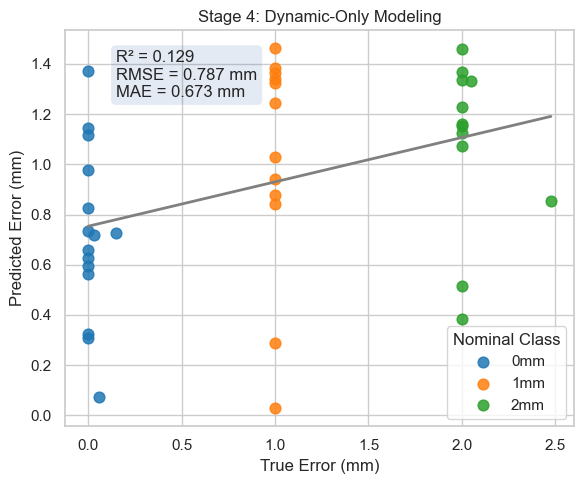

In [158]:
'''
DYNAMIC-ONLY EVAL PLOT
'''

plt.figure(figsize=(6, 5))

for cls, g in cv_pred_dynamic_df.groupby("Nominal_Class"):
    plt.scatter(
        g["y_true"],
        g["y_pred"],
        alpha=0.85,
        s=60,
        label=str(cls),
        color=class_colors.get(cls, None)
    )

lims = [
    min(cv_pred_dynamic_df["y_true"].min(), cv_pred_dynamic_df["y_pred"].min()),
    max(cv_pred_dynamic_df["y_true"].max(), cv_pred_dynamic_df["y_pred"].max())
]

m, b = np.polyfit(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"], 1)
xline = np.linspace(lims[0], lims[1], 100)
plt.plot(xline, m * xline + b, "-", color="gray", linewidth=2)

plt.xlabel("True Error (mm)")
plt.ylabel("Predicted Error (mm)")
plt.title("Stage 4: Dynamic-Only Modeling")
plt.grid(True)
plt.legend(title="Nominal Class")

txt = (
    f"R² = {r2_score(cv_pred_dynamic_df['y_true'], cv_pred_dynamic_df['y_pred']):.3f}\n"
    f"RMSE = {rmse(cv_pred_dynamic_df['y_true'], cv_pred_dynamic_df['y_pred']):.3f} mm\n"
    f"MAE = {mean_absolute_error(cv_pred_dynamic_df['y_true'], cv_pred_dynamic_df['y_pred']):.3f} mm"
)
plt.text(
    0.1, 0.95, txt,
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()

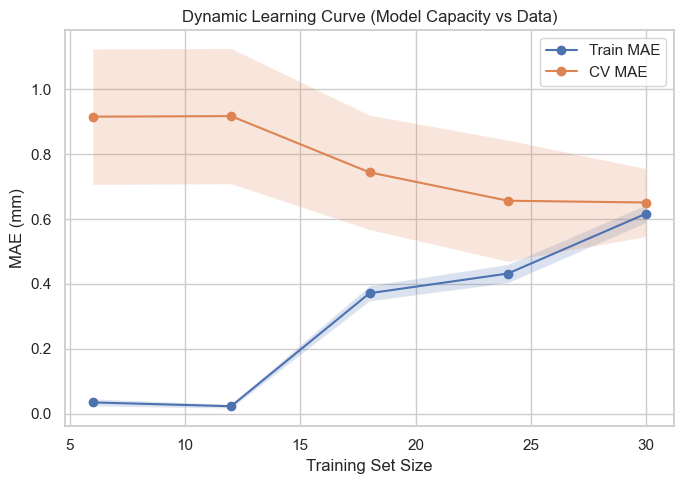

In [159]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
                                                            estimator=clone(primary_model),
                                                            X=X_dynamic_stage4,
                                                            y=y_dynamic_stage4,
                                                            groups=groups_dynamic,
                                                            cv=gkf_dynamic,
                                                            scoring="neg_mean_absolute_error",
                                                            train_sizes=np.linspace(0.2, 1.0, 5),
                                                            n_jobs=-1
                                                        )

train_mae = -train_scores.mean(axis=1)
train_mae_std = train_scores.std(axis=1)
val_mae = -val_scores.mean(axis=1)
val_mae_std = val_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mae, marker="o", label="Train MAE")
plt.fill_between(train_sizes, train_mae - train_mae_std, train_mae + train_mae_std, alpha=0.2)
plt.plot(train_sizes, val_mae, marker="o", label="CV MAE")
plt.fill_between(train_sizes, val_mae - val_mae_std, val_mae + val_mae_std, alpha=0.2)
plt.xlabel("Training Set Size")
plt.ylabel("MAE (mm)")
plt.title("Dynamic Learning Curve (Model Capacity vs Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [160]:
'''
DYNAMIC-ONLY CLASS SUMMARY
'''

dynamic_stage4_class_summary = (
    cv_pred_dynamic_df.groupby("Nominal_Class")
    .apply(lambda g: pd.Series({
        "mean_true": g["y_true"].mean(),
        "mean_pred": g["y_pred"].mean(),
        "std_true": g["y_true"].std(),
        "std_pred": g["y_pred"].std(),
        "MAE": np.mean(np.abs(g["y_true"] - g["y_pred"]))
    }))
    .reset_index()
)

display(dynamic_stage4_class_summary)

/var/folders/tv/8kr_xf_j7_12t3b_t5l75fs80000gn/T/ipykernel_99417/3110593500.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Nominal_Class,mean_true,mean_pred,std_true,std_pred,MAE
0,0mm,0.015561,0.717572,0.039553,0.342264,0.702011
1,1mm,1.000000,1.010339,0.000000,0.454028,0.347417
2,2mm,2.043651,1.082663,0.136974,0.337290,0.960988


In [161]:
results_dynamic_compare = pd.DataFrame([

    metric_row("Naive transfer (raw power_energy)", y_dynamic, y_pred_dynamic_naive),
    metric_row("Compensated transfer (within-trial normalized)", y_dynamic, y_pred_dynamic_comp),
    metric_row("Dynamic-only grouped CV (post-hoc)", cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]),

])

print("DYNAMIC MODEL COMPARISON")
print("------------------------")
display(results_dynamic_compare)

DYNAMIC MODEL COMPARISON
------------------------


,Model,R2,RMSE,MAE
0,Naive transfer (raw power_energy),-59.989750,6.582452,6.338316
1,Compensated transfer (within-trial normalized),-0.054809,0.865658,0.748616
2,Dynamic-only grouped CV (post-hoc),0.129209,0.786531,0.672591


---
### **RESULTS SUMMARIES**
---

In [162]:
summary_df = pd.DataFrame([{
    "Static_events": len(df_static),
    "Static_trial_files": groups_static.nunique(),
    "Dynamic_events": len(df_dynamic),
    "Dynamic_trial_files": groups_dynamic.nunique(),

    "Static_Grouped_CV_R2_mean": cv_r2_static.mean(),
    "Static_Grouped_CV_R2_std": cv_r2_static.std(),
    "Static_Grouped_CV_RMSE_mean": cv_rmse_static.mean(),
    "Static_Grouped_CV_MAE_mean": cv_mae_static.mean(),

    "Repeated_holdout_median_R2": repeated_results_df["R2"].median(),
    "Repeated_holdout_median_RMSE": repeated_results_df["RMSE"].median(),
    "Repeated_holdout_median_MAE": repeated_results_df["MAE"].median(),
    "Repeated_holdout_pct_R2_gt_0": (repeated_results_df["R2"] > 0).mean() * 100,

    "Dynamic_Naive_R2": r2_score(y_dynamic, y_pred_dynamic_naive),
    "Dynamic_Naive_RMSE": rmse(y_dynamic, y_pred_dynamic_naive),
    "Dynamic_Naive_MAE": mean_absolute_error(y_dynamic, y_pred_dynamic_naive),

    "Dynamic_Comp_R2": r2_score(y_dynamic, y_pred_dynamic_comp),
    "Dynamic_Comp_RMSE": rmse(y_dynamic, y_pred_dynamic_comp),
    "Dynamic_Comp_MAE": mean_absolute_error(y_dynamic, y_pred_dynamic_comp),

    "Dynamic_Only_CV_R2": r2_score(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]),
    "Dynamic_Only_CV_RMSE": rmse(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]),
    "Dynamic_Only_CV_MAE": mean_absolute_error(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]),
}])

print("FINAL REPORTING SUMMARY")
print("-----------------------")
display(summary_df)

FINAL REPORTING SUMMARY
-----------------------


,Static_events,Static_trial_files,Dynamic_events,Dynamic_trial_files,Static_Grouped_CV_R2_mean,Static_Grouped_CV_R2_std,Static_Grouped_CV_RMSE_mean,Static_Grouped_CV_MAE_mean,Repeated_holdout_median_R2,Repeated_holdout_median_RMSE,...,Repeated_holdout_pct_R2_gt_0,Dynamic_Naive_R2,Dynamic_Naive_RMSE,Dynamic_Naive_MAE,Dynamic_Comp_R2,Dynamic_Comp_RMSE,Dynamic_Comp_MAE,Dynamic_Only_CV_R2,Dynamic_Only_CV_RMSE,Dynamic_Only_CV_MAE
0,64,25,39,13,0.243938,0.279403,0.679762,0.627151,0.106968,0.747701,...,65.0,-59.98975,6.582452,6.338316,-0.054809,0.865658,0.748616,0.129209,0.786531,0.672591


In [163]:
compiled_results_df = pd.DataFrame([
    {
        "Analysis Stage": "Static learnability",
        "Dataset / Condition": "Static",
        "Features": "power_energy",
        "Evaluation Method": "Grouped CV",
        "R2": r2_score(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]),
        "RMSE_mm": rmse(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]),
        "MAE_mm": mean_absolute_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]),
        "Main Interpretation": "Event-level static mapping is learnable"
    },
    {
        "Analysis Stage": "Static robustness",
        "Dataset / Condition": "Static",
        "Features": "power_energy",
        "Evaluation Method": "Repeated grouped holdout (median)",
        "R2": repeated_results_df["R2"].median(),
        "RMSE_mm": repeated_results_df["RMSE"].median(),
        "MAE_mm": repeated_results_df["MAE"].median(),
        "Main Interpretation": "Performance is modest but often above chance"
    },
    {
        "Analysis Stage": "Naive transfer",
        "Dataset / Condition": "Dynamic",
        "Features": "raw power_energy",
        "Evaluation Method": "Static-trained transfer",
        "R2": r2_score(y_dynamic, y_pred_dynamic_naive),
        "RMSE_mm": rmse(y_dynamic, y_pred_dynamic_naive),
        "MAE_mm": mean_absolute_error(y_dynamic, y_pred_dynamic_naive),
        "Main Interpretation": "Direct static-to-dynamic transfer fails"
    },
    {
        "Analysis Stage": "Compensated transfer",
        "Dataset / Condition": "Dynamic",
        "Features": "within-trial normalized power_energy",
        "Evaluation Method": "Static-trained transfer",
        "R2": r2_score(y_dynamic, y_pred_dynamic_comp),
        "RMSE_mm": rmse(y_dynamic, y_pred_dynamic_comp),
        "MAE_mm": mean_absolute_error(y_dynamic, y_pred_dynamic_comp),
        "Main Interpretation": "Normalization partially recovers transfer"
    },
    {
        "Analysis Stage": "Dynamic-only post-hoc modeling",
        "Dataset / Condition": "Dynamic",
        "Features": "power_energy",
        "Evaluation Method": "Grouped CV within dynamic dataset",
        "R2": r2_score(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]),
        "RMSE_mm": rmse(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]),
        "MAE_mm": mean_absolute_error(cv_pred_dynamic_df["y_true"], cv_pred_dynamic_df["y_pred"]),
        "Main Interpretation": "Dynamic signal remains mappable with its own learned mapping"
    }
])

display(compiled_results_df)

,Analysis Stage,Dataset / Condition,Features,Evaluation Method,R2,RMSE_mm,MAE_mm,Main Interpretation
0,Static learnability,Static,power_energy,Grouped CV,0.218774,0.722343,0.623252,Event-level static mapping is learnable
1,Static robustness,Static,power_energy,Repeated grouped holdout (median),0.106968,0.747701,0.644780,Performance is modest but often above chance
2,Naive transfer,Dynamic,raw power_energy,Static-trained transfer,-59.989750,6.582452,6.338316,Direct static-to-dynamic transfer fails
3,Compensated transfer,Dynamic,within-trial normalized power_energy,Static-trained transfer,-0.054809,0.865658,0.748616,Normalization partially recovers transfer
4,Dynamic-only post-hoc modeling,Dynamic,power_energy,Grouped CV within dynamic dataset,0.129209,0.786531,0.672591,Dynamic signal remains mappable with its own l...


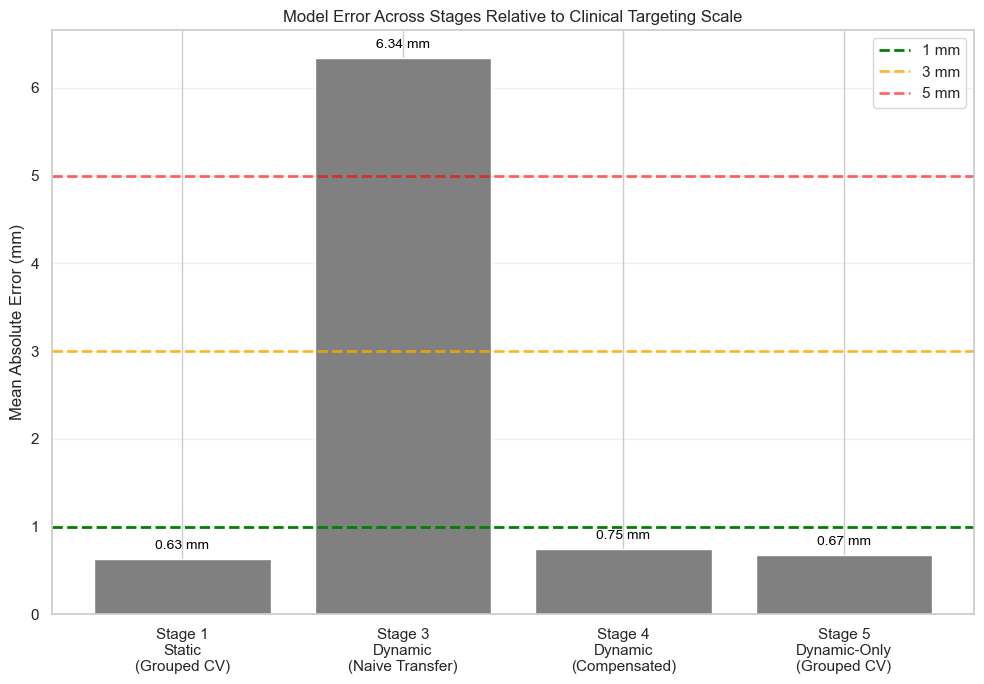

In [164]:
# =========================================================
# CLINICAL ERROR SCALE COMPARISON FIGURE
# using summary_df
# =========================================================

# Pull the single summary row
s = summary_df.iloc[0]

# Stage labels and MAE values
stages = [
    "Stage 1\nStatic\n(Grouped CV)",
    "Stage 3\nDynamic\n(Naive Transfer)",
    "Stage 4\nDynamic\n(Compensated)",
    "Stage 5\nDynamic-Only\n(Grouped CV)"
]

mae_values = [
    s["Static_Grouped_CV_MAE_mean"],
    s["Dynamic_Naive_MAE"],
    s["Dynamic_Comp_MAE"],
    s["Dynamic_Only_CV_MAE"]
]

# Plot
plt.figure(figsize=(10, 7))
bars = plt.bar(stages, mae_values, color="gray")

# Clinical reference lines
plt.axhline(1.0, linestyle="--", linewidth=2, color="green", label="1 mm")
plt.axhline(3.0, linestyle="--", linewidth=2, color="orange", alpha=0.8, label="3 mm")
plt.axhline(5.0, linestyle="--", linewidth=2, color="red", alpha=0.6, label="5 mm")

# Annotate bars
for i, v in enumerate(mae_values):
    plt.text(i, v + 0.08, f"{v:.2f} mm", ha="center", va="bottom", fontsize=10, color="black")

plt.ylabel("Mean Absolute Error (mm)")
plt.title("Model Error Across Stages Relative to Clinical Targeting Scale")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()